# Computational numerical derivatives

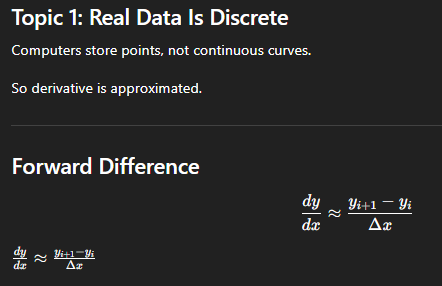

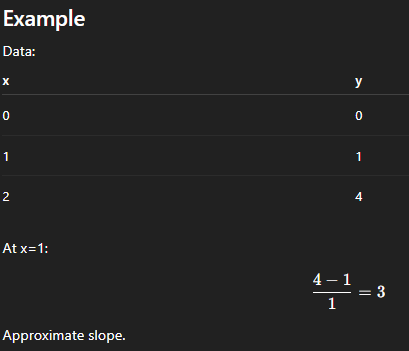

In [1]:
import numpy as np

x = np.array([0,1,2,3], dtype=float) # some points in x
C = np.array([10,8,6,4], dtype=float) # some function values at the points in x

dx = 1.0 # the spacing between the points in x (assuming uniform spacing)

grad = (C[1:] - C[:-1]) / dx # calculating the gradient (derivative) using finite difference
#C[1:]   → [8, 6, 4]
#C[:-1]  → [10, 8, 6]
# C[1:] - C[:-1] → [8-10, 6-8, 4-6] = [-2, -2, -2]
# Then divide by dx = 1:
# grad = [-2, -2, -2] / 1 = [-2, -2, -2]

print(grad)

[-2. -2. -2.]


# Compute flux

In [2]:
# Assume 
D = 0.5
J = -D * grad
print(J)

[1. 1. 1.]


# Additional indepth forward euler approximation
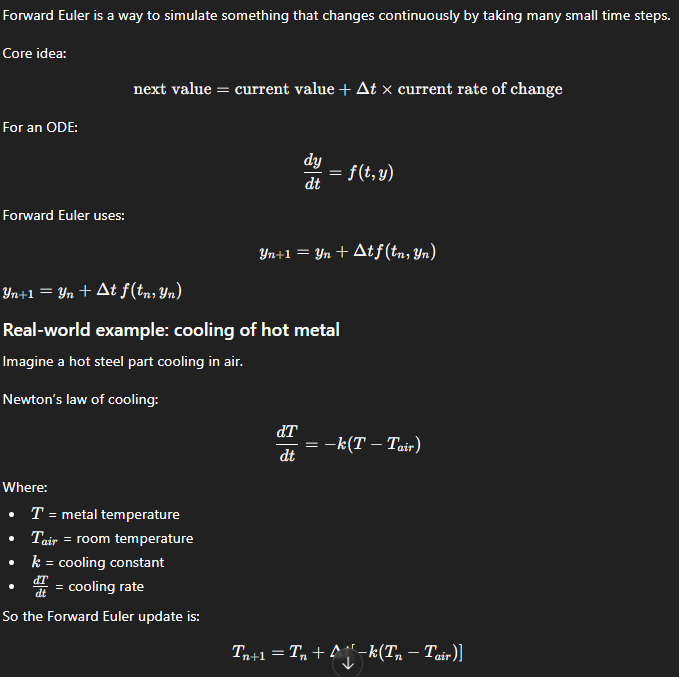

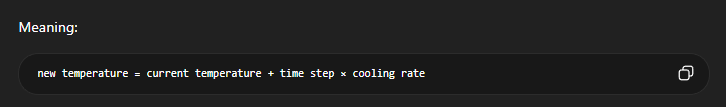

# Python simulation

Length of time array: 301
Initial temperature array: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Time step: 0
Temperature of me

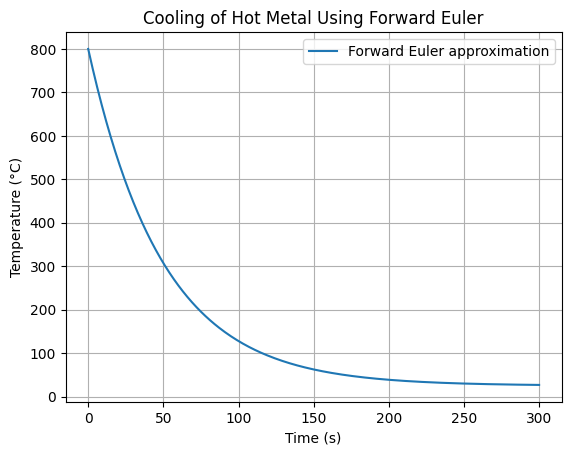

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
T_air = 25        # air temperature in °C
T0 = 800          # initial metal temperature in °C
k = 0.02          # cooling constant
dt = 1.0          # time step in seconds
total_time = 300  # total simulation time in seconds

# time array
t = np.arange(0, total_time + dt, dt) # time points from 0 to total_time with step dt
print(f"Length of time array: {len(t)}") # should be 301 points (0, 1, 2, ..., 300)

# temperature array
T = np.zeros(len(t)) # initialize temperature array
print(f"Initial temperature array: {T}") # should be an array of zeros with length 301
T[0] = T0 # set initial condition

# Forward Euler simulation
for n in range(len(t) - 1):    
    print(f"Time step: {n}")
    dTdt = -k * (T[n] - T_air)
    print(f"Temperature of metal at step {n} : {T[n]}")
    print(f"Derivative at step {n} is : {dTdt} and dependent on metal temperature {T[n]} and air temperature {T_air} and cooling constant {k}")
    T[n + 1] = T[n] + dt * dTdt
    print(f"Temperature of metal at step {n + 1}: {T[n + 1]} = {T[n]} + ({dt} * {dTdt})")

# plot
plt.plot(t, T, label="Forward Euler approximation")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Cooling of Hot Metal Using Forward Euler")
plt.grid(True)
plt.legend()
plt.show()

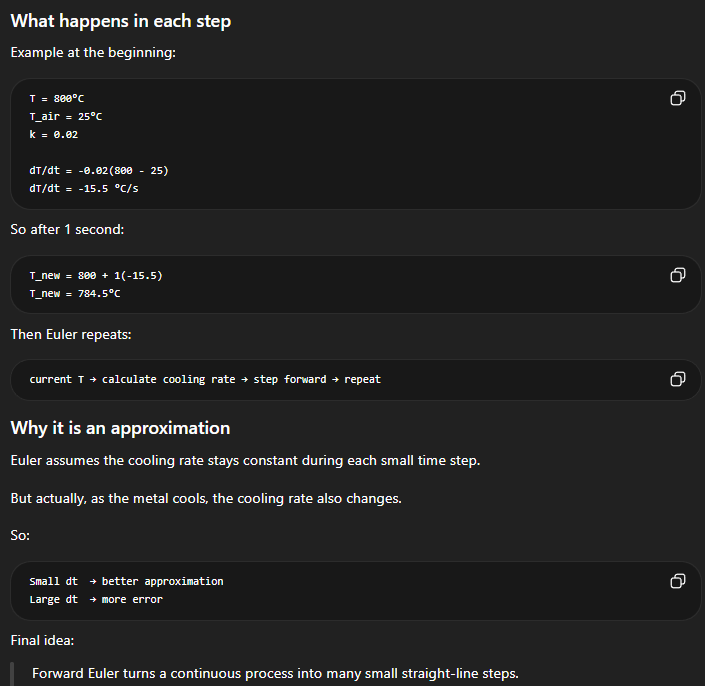

# How to compare it with true solution


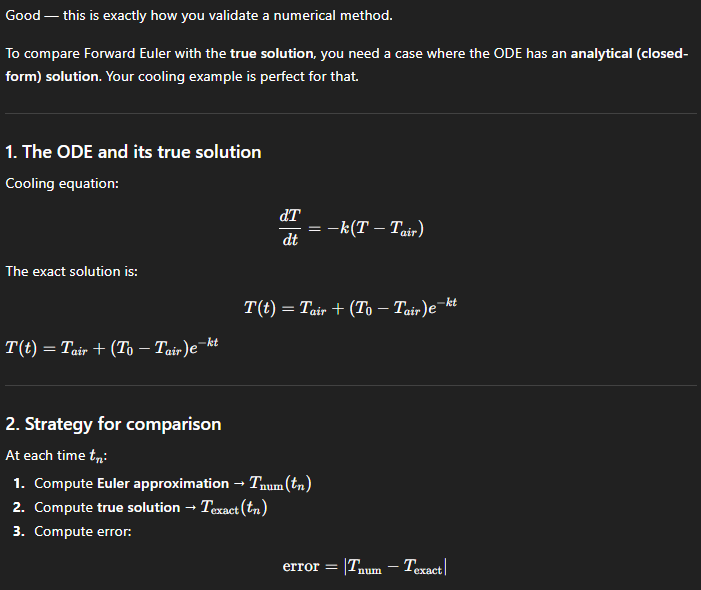

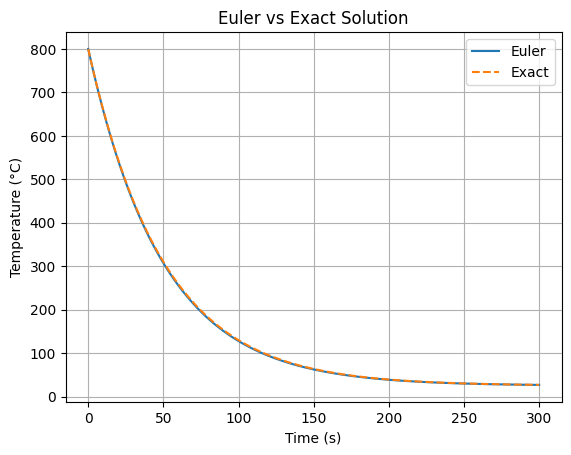

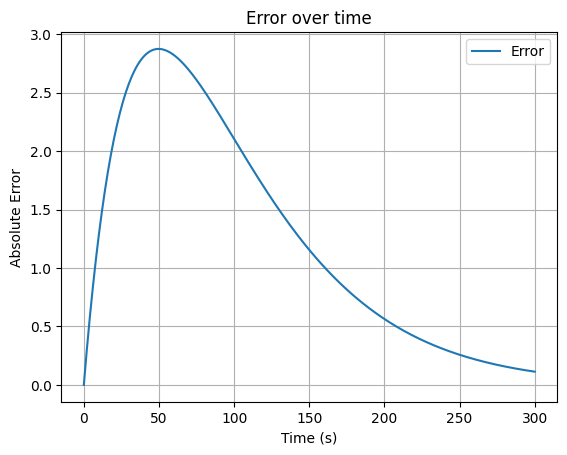

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
T_air = 25
T0 = 800
k = 0.02
dt = 1.0
total_time = 300

t = np.arange(0, total_time + dt, dt)

# Forward Euler
T_num = np.zeros(len(t))
T_num[0] = T0

for n in range(len(t) - 1):
    T_num[n+1] = T_num[n] + dt * (-k * (T_num[n] - T_air))

# Exact solution
T_exact = T_air + (T0 - T_air) * np.exp(-k * t)

# Error
error = np.abs(T_num - T_exact)

# Plot comparison
plt.figure()
plt.plot(t, T_num, label="Euler")
plt.plot(t, T_exact, '--', label="Exact")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Euler vs Exact Solution")
plt.legend()
plt.grid(True)

# Plot error
plt.figure()
plt.plot(t, error, label="Error")
plt.xlabel("Time (s)")
plt.ylabel("Absolute Error")
plt.title("Error over time")
plt.grid(True)
plt.legend()

plt.show()

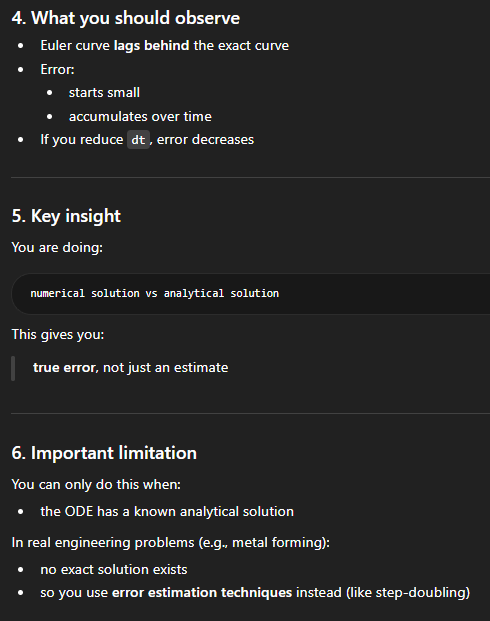

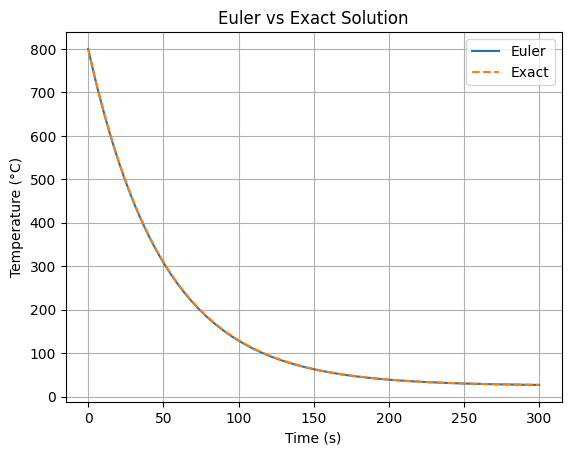

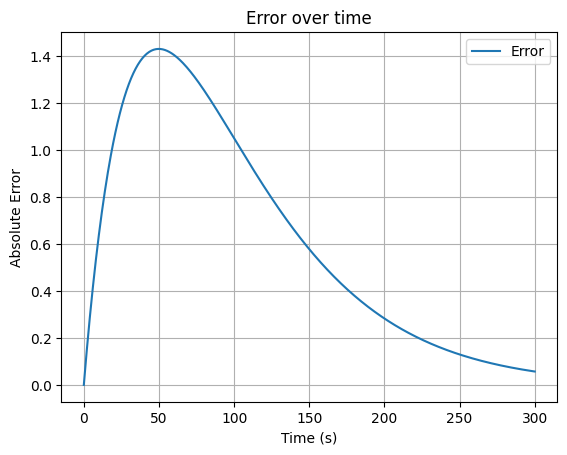

In [10]:
# first lets reduce the number of time steps and check the error. later we will look at step doubling.
import numpy as np
import matplotlib.pyplot as plt

# parameters
T_air = 25
T0 = 800
k = 0.02
dt = 0.5
total_time = 300

t = np.arange(0, total_time + dt, dt)

# Forward Euler
T_num = np.zeros(len(t))
T_num[0] = T0

for n in range(len(t) - 1):
    T_num[n+1] = T_num[n] + dt * (-k * (T_num[n] - T_air))

# Exact solution
T_exact = T_air + (T0 - T_air) * np.exp(-k * t)

# Error
error = np.abs(T_num - T_exact)

# Plot comparison
plt.figure()
plt.plot(t, T_num, label="Euler")
plt.plot(t, T_exact, '--', label="Exact")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Euler vs Exact Solution")
plt.legend()
plt.grid(True)

# Plot error
plt.figure()
plt.plot(t, error, label="Error")
plt.xlabel("Time (s)")
plt.ylabel("Absolute Error")
plt.title("Error over time")
plt.grid(True)
plt.legend()

plt.show()

we can see that the error has reduced by half by decreasing the time step by half

# Step doubling
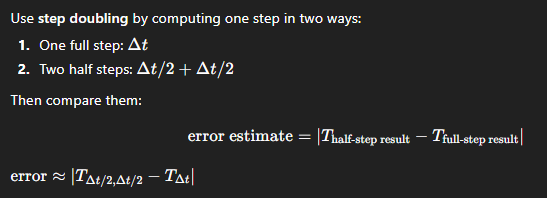

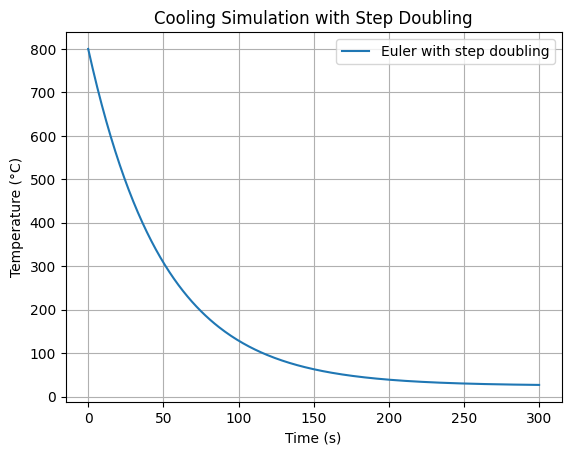

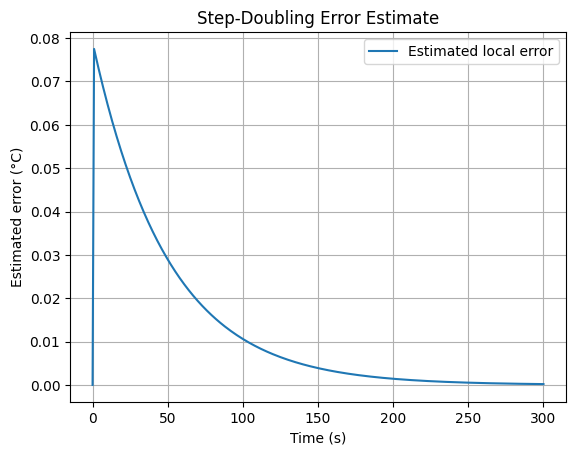

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
T_air = 25
T0 = 800
k = 0.02
dt = 1.0
total_time = 300

t = np.arange(0, total_time + dt, dt)

T = np.zeros(len(t))
T[0] = T0

error_est = np.zeros(len(t))

def f(T):
    return -k * (T - T_air)

for n in range(len(t) - 1):

    # one full Euler step
    T_full = T[n] + dt * f(T[n])

    # two half Euler steps
    dt_half = dt / 2

    T_half_1 = T[n] + dt_half * f(T[n])
    T_half_2 = T_half_1 + dt_half * f(T_half_1)

    # error estimate
    error_est[n + 1] = abs(T_half_2 - T_full)

    # use the more accurate result
    T[n + 1] = T_half_2

plt.figure()
plt.plot(t, T, label="Euler with step doubling")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Cooling Simulation with Step Doubling")
plt.grid(True)
plt.legend()

plt.figure()
plt.plot(t, error_est, label="Estimated local error")
plt.xlabel("Time (s)")
plt.ylabel("Estimated error (°C)")
plt.title("Step-Doubling Error Estimate")
plt.grid(True)
plt.legend()

plt.show()

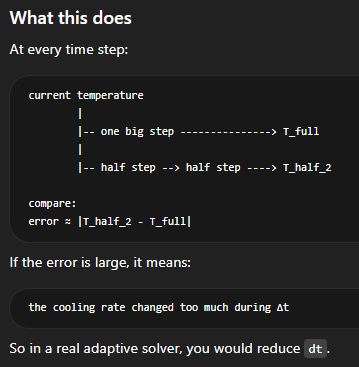